# Ćwiczenia z sieci neuronowych z PyTorch

## 1. Autograd

W bibliotece PyTorch, gdy wykonujemy operacje na tensorach z ustawioną flagą `requires_grad=True`, PyTorch automatycznie buduje graf obliczeniowy. Pozwala to na automatyczne liczenie gradientów (pochodnych) za pomocą funkcji `.backward()`, co jest kluczowe w uczeniu sieci neuronowych.

In [12]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

### Autograd na przykładzie działań na liczbach

Rozważmy prostą funkcję: $f(x, y) = x^3 + y^2$. Policzymy pochodne cząstkowe względem $x$ i $y$ dla $x=2$ i $y=4$.

In [13]:
x = torch.tensor([2.], requires_grad=True)
y = torch.tensor([4.], requires_grad=True)

f = x**3 + y**2
print(f'f = {f.item()}')

f.backward()
print(f'df/dx = {x.grad.item()}')  # Powinno być 3 * x^2 = 12
print(f'df/dy = {y.grad.item()}')  # Powinno być 2 * y = 8

f = 24.0
df/dx = 12.0
df/dy = 8.0


### Zadanie 1: autograd
Policz za pomocą PyTorcha gradienty funkcji $g(x, y) = \sin(x \cdot y) / \sin(x)$ dla $x=1.0$ i $y=3.0$.

Użyj `torch.sin`

Oczekiwany wynik:

$\frac{\partial g}{\partial x} = \frac{y \cos(xy) \sin(x) - \sin(xy) \cos(x)}{\sin^2(x)}$

$\frac{\partial g}{\partial y} = \frac{x \cos(xy)}{\sin(x)}$ 

Podstawiając wartości do pochodnych cząstkowych dla $x=1.0$ i $y=3.0$:

$\frac{\partial g}{\partial x} \approx -3.637$
$\frac{\partial g}{\partial y} \approx -1.177$

In [14]:
x = 1.0
y = 3.0

print(f"dg/dx (exact calculated)= {(y * np.cos(x*y)*np.sin(x) - np.sin(x*y)*np.cos(x))/np.sin(x)**2:0.3f}")
print(f"dg/dy (exact calculated) = {x * np.cos(x*y)/np.sin(x):0.3f}")

dg/dx (exact calculated)= -3.637
dg/dy (exact calculated) = -1.177


In [15]:
# Miejsce na kod


### MSE dla pojedynczej próbki

Policzmy błąd średniokwadratowy (MSE) dla prawdziwej wartości $y$ oraz predykcji $\hat{y} = W \cdot X$ i gradienty względem $W$.

In [16]:
X = torch.tensor([[1.5, 2.0]])  # Kształt (1, 2) - jeden wektor cech
W = torch.tensor([[0.5, -0.2]], requires_grad=True) # Wagi, kształt (1, 2)
y_true = torch.tensor([[1.0]])

# Predykcja (iloczyn skalarny - dla ułatwienia używamy transpozycji W)
y_pred = torch.matmul(X, W.T)

# Błąd średniokwadratowy (MSE)
loss = (y_pred - y_true)**2

print(f'Predykcja: {y_pred.item():.4f}, Loss: {loss.item():.4f}')

loss.backward()
print(f'Gradienty względem W:\n{W.grad}')

Predykcja: 0.3500, Loss: 0.4225
Gradienty względem W:
tensor([[-1.9500, -2.6000]])


### Autograd na batchu

Operacje na jednym przykładzie są rzadkie, zazwyczaj używamy tzw. batchy, czyli paczek danych. Operacje w PyTorch są wektoryzowane, a strata (loss) jest najczęściej średnią po całym batchu.

In [17]:
X_batch = torch.tensor([[1.5, 2.0], [0.5, -1.0], [2.0, 1.0]]) # Batch 3 elementów
y_true_batch = torch.tensor([[1.0], [0.0], [1.5]])

# Przed użyciem tych samych wag w nowym kroku, musimy wyzerować poprzednie gradienty!
if W.grad is not None:
    W.grad.zero_()

y_pred_batch = torch.matmul(X_batch, W.T)

# MSE dla całego batcha
loss_batch = torch.mean((y_pred_batch - y_true_batch)**2)

loss_batch.backward()
print(f'Gradienty względem W (batch):\n{W.grad}')

Gradienty względem W (batch):
tensor([[-1.4333, -1.6333]])


## 2. Pętla ucząca

Teraz, gdy potrafimy już liczyć gradienty, zbudujmy prostą pętlę uczącą z tzw. spadkiem wzdłuż gradientu (Gradient Descent). Zaktualizujemy wagi za pomocą reguły: `W = W - lr * W.grad`.

In [18]:
# Generowanie sztucznych danych liniowych
num_samples = 100
X_data = torch.randn(num_samples, 2)
true_W = torch.tensor([[2.0, -3.0]])
y_data = torch.matmul(X_data, true_W.T) + 0.1 * torch.randn(num_samples, 1) # Dodajemy szum

### Trenowanie modelu z jednym batchem (całym zbiorem) - brak optymalizatora
Zrobimy 100 kroków uczenia.

Epoch 0, Loss: 4.5091
Epoch 20, Loss: 0.0120
Epoch 40, Loss: 0.0111
Epoch 60, Loss: 0.0111
Epoch 80, Loss: 0.0111
Wyuczone W: tensor([[ 1.9990, -2.9959]]), Prawdziwe W: tensor([[ 2., -3.]])


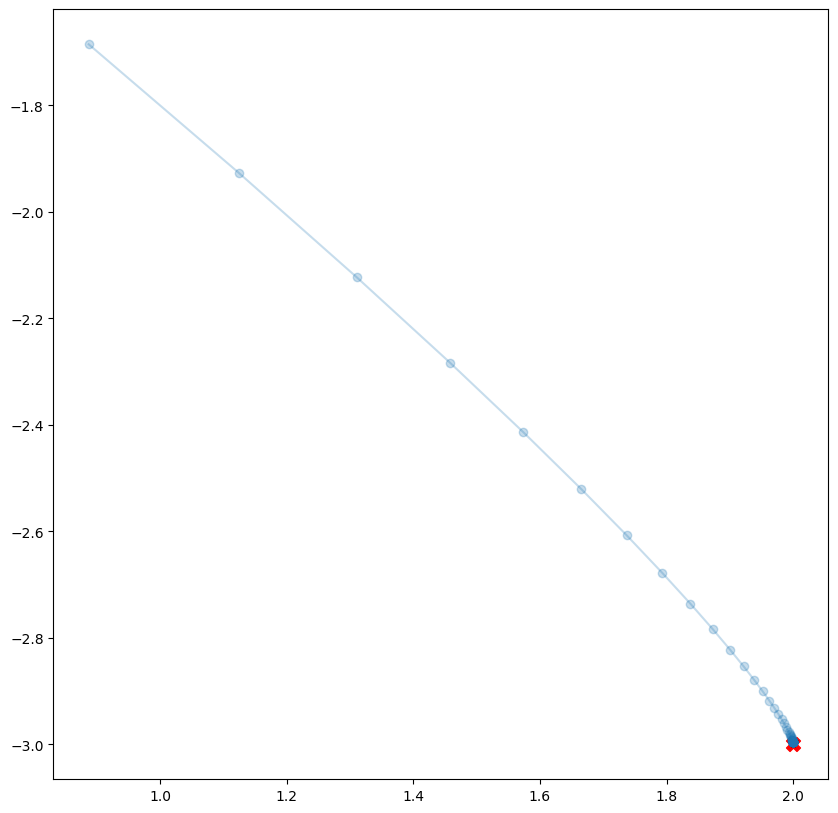

In [19]:
W = torch.randn(1, 2, requires_grad=True)
lr = 0.1

fig = plt.figure(figsize=(10,10))
plt.scatter([true_W[0,0].item()], [true_W[0,1].item()], color='red', label='Prawdziwe W', marker='X', s=100)

estimated_Ws = []
for epoch in range(100):
    # 1. Forward pass
    y_pred = torch.matmul(X_data, W.T)
    
    # 2. Obliczenie straty
    loss = torch.mean((y_pred - y_data)**2)
    
    # 3. Backward pass (obliczenie gradientów)
    loss.backward()
    
    # 4. Aktualizacja wag (wyłączamy śledzenie gradientów na czas aktualizacji)
    with torch.no_grad():
        W -= lr * W.grad
        W.grad.zero_() # Zerowanie gradientów po aktualizacji!
        
    if epoch % 20 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')
        
    estimated_Ws.append(W.data.squeeze().tolist())

estimated_Ws = np.array(estimated_Ws)  # Kształt (num_epochs, 2)
plt.plot(estimated_Ws[:, 0], estimated_Ws[:, 1], marker='o', label='Wyuczone W', alpha=0.25)

print(f'Wyuczone W: {W.data}, Prawdziwe W: {true_W.data}')

### Trenowanie modelu w pętli z batchami (minibatch gradient descent)

Epoch 0, Loss: 0.0601
Epoch 10, Loss: 0.0054
Epoch 20, Loss: 0.0041
Epoch 30, Loss: 0.0141
Epoch 40, Loss: 0.0143
Wyuczone W (minibatch): tensor([[ 2.0234, -2.9922]])


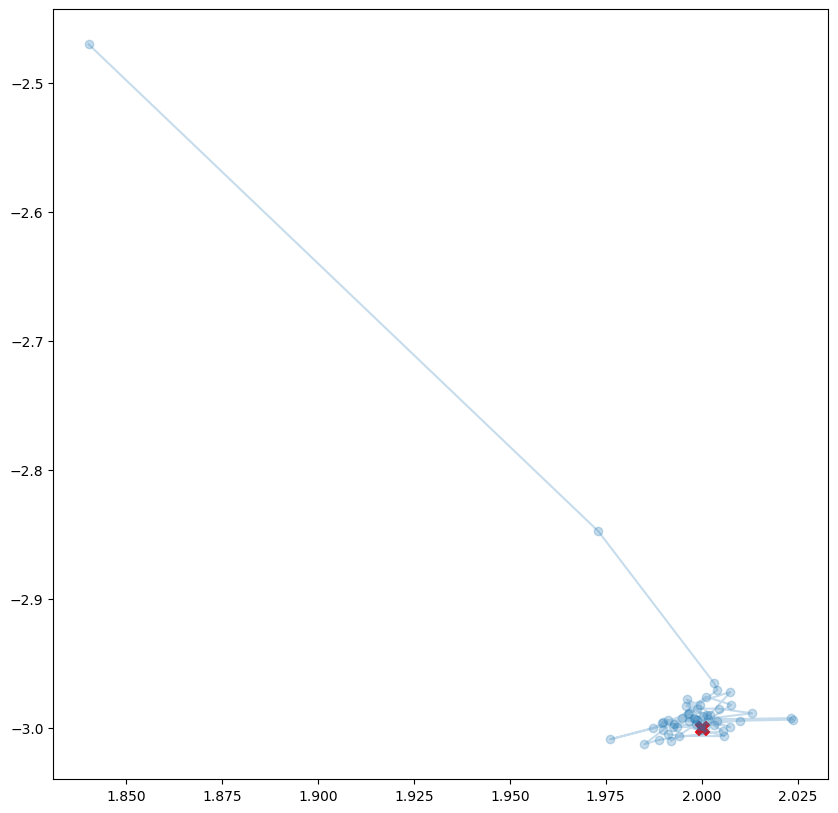

In [20]:
W = torch.randn(1, 2, requires_grad=True)
batch_size = 16
epochs = 50
lr = 0.1

plt.figure(figsize=(10,10))
plt.scatter([true_W[0,0].item()], [true_W[0,1].item()], color='red', label='Prawdziwe W', marker='X', s=100)

estimated_Ws = []
for epoch in range(epochs):
    # Mieszanie danych to dobra praktyka!
    indices = torch.randperm(num_samples)
    X_shuffled = X_data[indices]
    y_shuffled = y_data[indices]
    
    for i in range(0, num_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # forward
        y_pred = torch.matmul(X_batch, W.T)
        loss = torch.mean((y_pred - y_batch)**2)
        
        # backward
        loss.backward()
        
        # update
        with torch.no_grad():
            W -= lr * W.grad
            W.grad.zero_()
    
    estimated_Ws.append(W.data.squeeze().tolist())
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

estimated_Ws = np.array(estimated_Ws)  # Kształt (num_epochs, 2)
plt.plot(estimated_Ws[:, 0], estimated_Ws[:, 1], marker='o', label='Wyuczone W (minibatch)', alpha=0.25)
print(f'Wyuczone W (minibatch): {W.data}')

## 3. Modele w PyTorch

Zamiast ręcznie zarządzać wagami jako tensorami, w PyTorch tworzymy klasy dziedziczące po `nn.Module`. Pozwala to łatwiej organizować warstwy.

In [21]:
class SuperSimpleModel(nn.Module):
    def __init__(self, a=1.0, b=0.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(a, dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor(b, dtype=torch.float32))

    def forward(self, x):
        return self.a * x + self.b

model = SuperSimpleModel(a=4)
print(list(model.parameters()))

input_data = torch.tensor([[1.0], [2.0], [3.0]])
print(f'Input data:\n{input_data}')
output = model(input_data)
print(f'Output modelu:\n{output}')

[Parameter containing:
tensor(4., requires_grad=True), Parameter containing:
tensor(0., requires_grad=True)]
Input data:
tensor([[1.],
        [2.],
        [3.]])
Output modelu:
tensor([[ 4.],
        [ 8.],
        [12.]], grad_fn=<AddBackward0>)


### Zadanie 2: połączenie rezydualne

Skopiuj klasę powyżej i zmodyfikuj ją tak, aby posiadała tzw. połączenie rezydualne (residual connection).

In [22]:
# Miejsce na kod
# class ResidualSuperSimpleModel(nn.Module):
#     def __init__(self, a=1.0, b=0.0):
#         super().__init__()
#         ...

# # lub wykorzystując dziedziczenie po SuperSimpleModel
# class ResidualSuperSimpleModel(SuperSimpleModel):
#     ...

# model = ResidualSuperSimpleModel(a=2, b=1.3)
# print(list(model.parameters()))

# input_data = torch.tensor([[1.0], [2.0], [3.0]])
# print(f'Input data:\n{input_data}')
# output = model(input_data)
# print(f'Output modelu:\n{output}')



### Model z warstwą nn.Linear

Zamiast pisać własne mnożenie przez wagi, używamy gotowych warstw.

In [23]:
class LinearModel(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        
    def forward(self, x):
        return self.linear(x)

model_lin = LinearModel(2, 1)
print(model_lin(X_data[:5]))

tensor([[ 0.3062],
        [ 0.4327],
        [-0.4139],
        [ 0.2843],
        [ 0.0919]], grad_fn=<AddmmBackward0>)


### Prosty MLP (Multi-Layer Perceptron)

Sieć wielowarstwowa wymaga dodania nieliniowości między warstwami, np. ReLU.

In [24]:
class SimpleMLP(nn.Module):
    def __init__(self, in_features, hidden_size, out_features):
        super().__init__()
        self.linear1 = nn.Linear(in_features, hidden_size)
        self.activation = nn.ReLU()
        self.linear2 = nn.Linear(hidden_size, out_features)
        
    def forward(self, x): # (batch_size, in_features)
        x = self.linear1(x) # (batch_size, hidden_size)
        x = self.activation(x) # (batch_size, hidden_size)
        x = self.linear2(x) # (batch_size, out_features)
        return x

class SimpleMLPUsingSequential(nn.Module):
    def __init__(self, in_features, hidden_size, out_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, out_features)
        )
        
    def forward(self, x):
        return self.net(x)

### Zadanie 3: zaawansowany MLP

Uzupełnij klasę `AdvancedMLP`, zawierającą warstwy liniowe, aktywacji, dropout, normalizacje i połącznia rezydualne

Kolejność w bloku (jeśli wszystkie warstwy występują):

- normalizacja
- transformacja liniowa
- aktywacja (nieliniowość)
- dropout


In [25]:
# uzupełnienie kodu
class AdvancedMLP(nn.Module):
    def __init__(self, in_features, hidden_size, out_features, dropout_prob=0.1):
        super().__init__()
        
        self.linear1 = nn.Linear(in_features, hidden_size)
        self.act1 = nn.GELU()
        self.drop1 = nn.Dropout(dropout_prob)

        self.norm2 = nn.LayerNorm(hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.act2 = nn.GELU()
        self.drop2 = nn.Dropout(dropout_prob)

        # Output Layer
        self.linear_out = nn.Linear(hidden_size, out_features)

    def forward(self, x):
        """
        Input x: (batch_size, in_features)
        """

        # block 1: linear + activation + dropout
        # na wejściu nie robimy normalizacji, żeby zachować informację o skali cech
        # out = ...          # (batch_size, hidden_size)
        # out = ...         # (batch_size, hidden_size)
        # out = ...        # (batch_size, hidden_size)
        
        # block 2 normalizacja + linear + activation + dropout + residual
        residual = out 
        
        # out = ...        # (batch_size, hidden_size)
        # out = ...          # (batch_size, hidden_size)
        # out = ...         # (batch_size, hidden_size)
        # out = ...        # (batch_size, hidden_size)
        
        # połączenie z residualem
        # out = ... + ...         # (batch_size, hidden_size)


        return self.linear_out(out)      # (batch_size, out_features)

## 4. Pętla ucząca dla MLP

Przećwiczymy naszą wiedzę na nieco trudniejszym problemie (nieliniowym).

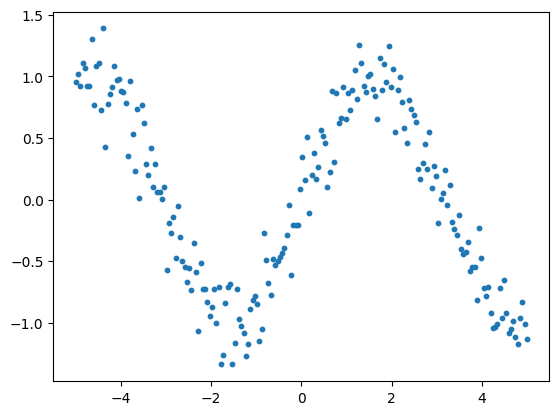

In [26]:
# Generujemy dane nieliniowe (np. funkcja sinus z szumem)
X_nl = torch.linspace(-5, 5, 200).unsqueeze(1)
y_nl = torch.sin(X_nl) + 0.2 * torch.randn(X_nl.size())

plt.scatter(X_nl.numpy(), y_nl.numpy(), s=10)
plt.show()

### Pętla ucząca dla MLP bez optymalizatora (ręczna aktualizacja `nn.Parameter` z `model.parameters()`)

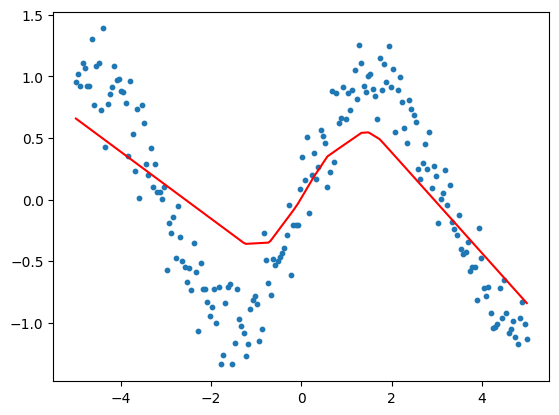

In [27]:
model_mlp = SimpleMLP(1, 16, 1)
# model_mlp = AdvancedMLP(1, 16, 1) # Możesz też przetestować bardziej zaawansowany model!
lr = 0.01

for epoch in range(300):
    y_pred = model_mlp(X_nl)
    loss = torch.mean((y_pred - y_nl)**2)
    loss.backward()
    
    with torch.no_grad():
        for p in model_mlp.parameters():
            p -= lr * p.grad
            p.grad.zero_()

plt.scatter(X_nl.numpy(), y_nl.numpy(), s=10)
plt.plot(X_nl.numpy(), model_mlp(X_nl).detach().numpy(), color='red')
plt.show()

### Pętla ucząca z optymalizatorem (torch.optim)

Zamiast ręcznej pętli `for p in model.parameters()`, używamy np. `torch.optim.Adam`.

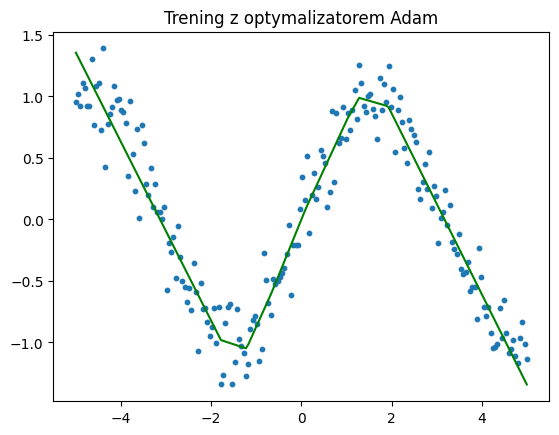

In [28]:
model_mlp_opt = SimpleMLP(1, 16, 1)
# model_mlp_opt = AdvancedMLP(1, 128, 1) # Możesz też przetestować bardziej zaawansowany model!
optimizer = torch.optim.Adam(model_mlp_opt.parameters(), lr=0.05)
criterion = nn.MSELoss()

for epoch in range(300):
    optimizer.zero_grad()      # Zerujemy gradienty PRZED forward/backward!
    y_pred = model_mlp_opt(X_nl)
    loss = criterion(y_pred, y_nl)
    loss.backward()            # Liczymy gradienty
    optimizer.step()           # Optymalizator aktualizuje wagi

plt.scatter(X_nl.numpy(), y_nl.numpy(), s=10)
plt.plot(X_nl.numpy(), model_mlp_opt(X_nl).detach().numpy(), color='green')
plt.title("Trening z optymalizatorem Adam")
plt.show()

## 5. Kompleksowa pętla ucząca

Zazwyczaj chcemy mierzyć stratę nie tylko na zbiorze treningowym, ale również na walidacyjnym, zapisywać jej historię do wykresów, a także zapisywać najlepsze wagi modelu (tzw. checkpoints).

Epoch   0/500 | Train Loss: 0.6689 | Val Loss: 0.3377
Epoch  50/500 | Train Loss: 0.0508 | Val Loss: 0.0403
Epoch 100/500 | Train Loss: 0.0460 | Val Loss: 0.0487
Epoch 150/500 | Train Loss: 0.0476 | Val Loss: 0.0354
Epoch 200/500 | Train Loss: 0.0491 | Val Loss: 0.0339
Epoch 250/500 | Train Loss: 0.0460 | Val Loss: 0.0422
Epoch 300/500 | Train Loss: 0.0479 | Val Loss: 0.0408
Epoch 350/500 | Train Loss: 0.0491 | Val Loss: 0.0517
Epoch 400/500 | Train Loss: 0.0438 | Val Loss: 0.0434
Epoch 450/500 | Train Loss: 0.0462 | Val Loss: 0.0493
Uczenie zakończone. Ładowanie najlepszych wag...


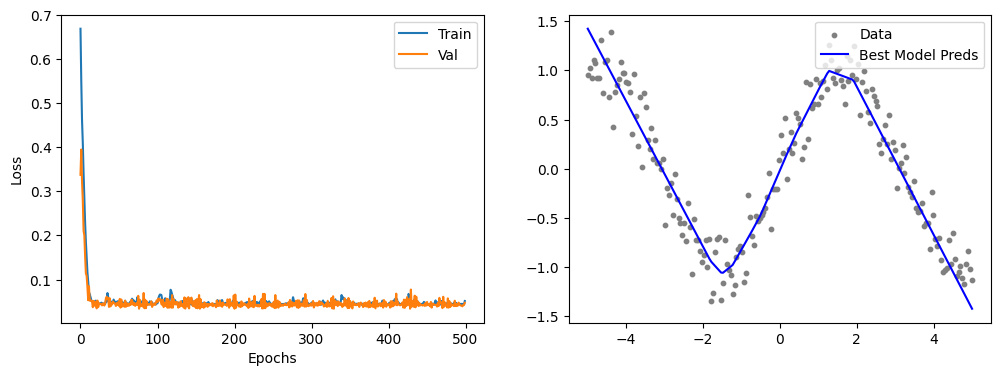

In [29]:
import copy

# Podział danych na train / val
indices = torch.randperm(len(X_nl))
train_idx, val_idx = indices[:150], indices[150:]
X_train, y_train = X_nl[train_idx], y_nl[train_idx]
X_val, y_val = X_nl[val_idx], y_nl[val_idx]

model_full = SimpleMLP(1, 32, 1)
# model_full = AdvancedMLP(1, 32, 1) # Możesz też przetestować bardziej zaawansowany model!
optimizer = torch.optim.Adam(model_full.parameters(), lr=0.01)
criterion = nn.MSELoss()

epochs = 500
batch_size = 32

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
best_model_wts = None

for epoch in range(epochs):
    # Faza treningu
    model_full.train()
    train_losses = []
    
    perm = torch.randperm(len(X_train))
    X_tr_shuffled = X_train[perm]
    y_tr_shuffled = y_train[perm]
    
    for i in range(0, len(X_train), batch_size):
        X_b = X_tr_shuffled[i:i+batch_size]
        y_b = y_tr_shuffled[i:i+batch_size]
        
        optimizer.zero_grad()
        preds = model_full(X_b)
        loss = criterion(preds, y_b)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        
    avg_train_loss = np.mean(train_losses)
    history['train_loss'].append(avg_train_loss)
    
    # Faza ewaluacji (walidacji)
    model_full.eval()
    with torch.no_grad():
        val_preds = model_full(X_val)
        val_loss = criterion(val_preds, y_val).item()
        history['val_loss'].append(val_loss)
        
    # Checkpointing najlepszego modelu (do zmiennej, zamiast do pliku)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model_full.state_dict())
        
    if epoch % 50 == 0:
        print(f'Epoch {epoch:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}')

print("Uczenie zakończone. Ładowanie najlepszych wag...")
model_full.load_state_dict(best_model_wts)

# Wykres historii uczenia
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Wykres dopasowania najlepszego modelu
plt.subplot(1, 2, 2)
plt.scatter(X_nl.numpy(), y_nl.numpy(), s=10, label='Data', color='gray')
# Sortowanie do ładnego rysowania linii
x_sorted, _ = torch.sort(X_nl, dim=0)
model_full.eval()
with torch.no_grad():
    preds_sorted = model_full(x_sorted)
plt.plot(x_sorted.numpy(), preds_sorted.numpy(), color='blue', label='Best Model Preds')
plt.legend()
plt.show()

# Rozwiązania zadań

## Zadanie 1: autograd

In [30]:
x = torch.tensor([1.0], requires_grad=True)
y = torch.tensor([3.0], requires_grad=True)

g = torch.sin(x*y)/torch.sin(x)
g.backward()

print(f'dg/dx = {x.grad.item()}')
print(f'dg/dy = {y.grad.item()}')

dg/dx = -3.6371896266937256
dg/dy = -1.1765022277832031


## Zadanie2: prosty MLP

In [31]:
class ResidualSuperSimpleModel(nn.Module):
    def __init__(self, a=1.0, b=0.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(a, dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor(b, dtype=torch.float32))

    def forward(self, x):
        return x + self.a * x + self.b

# lub wykorzystując dziedziczenie

class ResidualSuperSimpleModel(SuperSimpleModel): # 
    def forward(self, x):
        return super().forward(x) + x



## Zadanie 3: zaawansowany MLP

In [32]:
# rozwiązanie
class AdvancedMLP(nn.Module):
    def __init__(self, in_features, hidden_size, out_features, dropout_prob=0.1):
        super().__init__()
        
        self.linear1 = nn.Linear(in_features, hidden_size)
        self.act1 = nn.GELU()
        self.drop1 = nn.Dropout(dropout_prob)

        self.norm2 = nn.LayerNorm(hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.act2 = nn.GELU()
        self.drop2 = nn.Dropout(dropout_prob)

        # Output Layer
        self.linear_out = nn.Linear(hidden_size, out_features)

    def forward(self, x):
        """
        Input x: (batch_size, in_features)
        """

        # block 1
        # na wejściu nie robimy normalizacji, żeby zachować informację o skali cech
        out = self.linear1(x)          # (batch_size, hidden_size)
        out = self.act1(out)         # (batch_size, hidden_size)
        out = self.drop1(out)        # (batch_size, hidden_size)
        
        # block 2
        residual = out 
        
        out = self.norm2(out)        # (batch_size, hidden_size)
        out = self.linear2(out)          # (batch_size, hidden_size)
        out = self.act2(out)         # (batch_size, hidden_size)
        out = self.drop2(out)        # (batch_size, hidden_size)
        
        out = out + residual         # (batch_size, hidden_size)


        return self.linear_out(out)      # (batch_size, out_features)